In [26]:
# Moja pierwsza komórka
print("Witaj w Jupyter Notebook!")
2 + 2

Witaj w Jupyter Notebook!


4

## Krok 1: Import bibliotek

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

## Krok 2: Wczytanie danych
Dataset: rachunki z restauracji (244 obserwacje, 7 zmiennych).

In [28]:
df = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv')
print(f"Dane wczytane: {df.shape[0]} wierszy, {df.shape[1]} kolumn")

Dane wczytane: 244 wierszy, 7 kolumn


## Krok 3: Poznanie danych

In [29]:
# Pierwsze 5 wierszy — ZAWSZE zacznij od tego!
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [30]:
# Pierwsze 5 wierszy — ZAWSZE zacznij od tego!
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [31]:
# Informacje o typach i brakujących danych
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


In [32]:
# Informacje o typach i brakujących danych
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


In [33]:
# Typy danych w każdej kolumnie
df.dtypes

total_bill    float64
tip           float64
sex            object
smoker         object
day            object
time           object
size            int64
dtype: object

In [34]:
# Nazwy kolumn
df.columns.tolist()

['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']

## Wnioski z eksploracji
- Dataset zawiera 5 wierszy i 7 kolumn
- Kolumny numeryczne: total_bill, tip
- Kolumny tekstowe: sex, smoker, day, time
- Brakujące wartości:  nie ma brakujących danych (sprawdź wynik info())
- Średni rachunek wynosi 19.79 $

## Pytania biznesowe

In [35]:
df['total_bill'].max() # największa wartość
df['total_bill'].min() # najmniejsza wartość
df['total_bill'].mean() # średnia

19.78594262295082

# Pytanie 1: Najwyższy rachunek


In [36]:
df['total_bill'].max()

50.81

# Pytanie 2: Rachunki wg dnia

In [37]:
df['day'].value_counts() 

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

# Pytanie 3: Napiwki — palący vs niepalący

In [38]:
df.groupby('smoker')['tip'].mean()


smoker
No     2.991854
Yes    3.008710
Name: tip, dtype: float64

# Pytanie 4: Procent napiwku

In [39]:
df['tip_percent'] = df['tip'] / df['total_bill'] * 100

In [40]:
df['tip_percent'].mean()

16.08025817225047

# Pytanie 5: Dzień + pora → rachunki

In [41]:
df.groupby(['day', 'time'])['total_bill'].mean()

day   time  
Fri   Dinner    19.663333
      Lunch     12.845714
Sat   Dinner    20.441379
Sun   Dinner    21.410000
Thur  Dinner    18.780000
      Lunch     17.664754
Name: total_bill, dtype: float64

## Wizualizacja

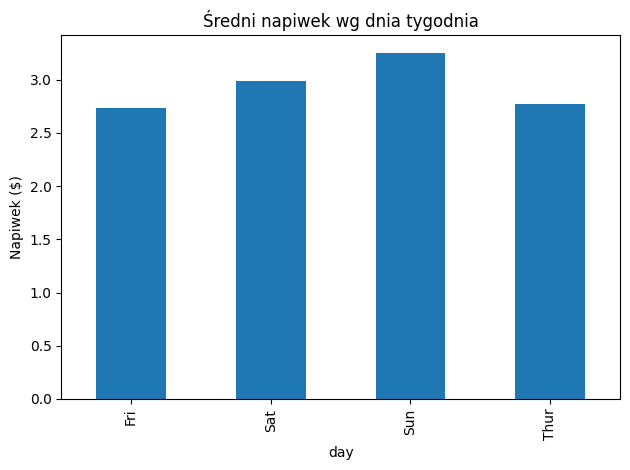

In [42]:
# Średni napiwek wg dnia tygodnia
df.groupby('day')['tip'].mean().plot(kind='bar', title='Średni napiwek wg dnia tygodnia')
plt.ylabel('Napiwek ($)')
plt.tight_layout()
plt.show()

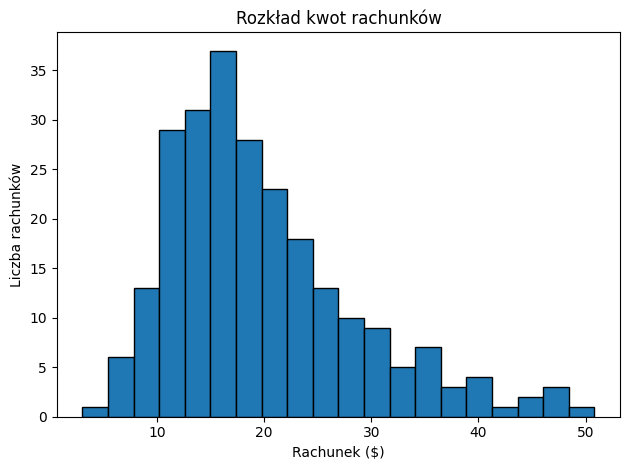

In [43]:
# Rozkład rachunków — histogram
df['total_bill'].plot(kind='hist', bins=20, title='Rozkład kwot rachunków', edgecolor='black')
plt.xlabel('Rachunek ($)')
plt.ylabel('Liczba rachunków')
plt.tight_layout()
plt.show()